# FEniCS Demo

## Solving the Poisson Equation in 2D

Let us consider the the following boundary-value problem:

$$-\nabla^2 u(\bm{x}) = f(\bm{x}), \quad \bm{x} \in \Omega$$
$$u(\bm{x}) = u_D(\bm{x}), \quad \bm{x} \in \partial\Omega$$
where $f=f(\bm{x})$ and $u_D(\bm{x})$ are given functions, and $\Omega$ is the spatial domain with a boudnary $\partial\Omega$.

### Manufactured Solution
Define
$$u_\text{exact}(x,y) = 1 + x^2 + y^2$$
on the unit square $\Omega = [0,1] \times [0,1]$, so that
$$f(x,y)=-6,\qquad u_D\big|_{\partial\Omega} = 1+x^2+2y^2$$

In [31]:
# add import statements
import numpy as np
from mpi4py import MPI
from dolfinx import mesh, fem
from dolfinx.fem.petsc import LinearProblem
import ufl
import matplotlib.pyplot as plt
from scipy import stats

In [32]:
def solve_poisson_problem(N):
    # create mesh
    domain = mesh.create_unit_square(MPI.COMM_WORLD, N, N)

    # define the function space
    V = fem.functionspace(domain, ("Lagrange", 1))

    # define the trial and test functions
    u = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)
    f = fem.Constant(domain, -6.0)
    
    # handle Dirichlet boudnary conditions
    uD = fem.Function(V)
    uD.interpolate(lambda x: 1 + x[0]**2 + 2*x[1]**2)
    # determine the degrees of freedom on the boundary of the mesh
    tdim = domain.topology.dim
    fdim = tdim - 1
    domain.topology.create_connectivity(fdim, tdim)
    boundary_facets = mesh.exterior_facet_indices(domain.topology)
    boundary_dofs = fem.locate_dofs_topological(V, fdim, boundary_facets)
    bc = fem.dirichletbc(uD, boundary_dofs)

    # define the varational problem
    a = ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
    L = f * v * ufl.dx

    # solve the linear system
    problem = fem.petsc.LinearProblem(a, L, bcs=[bc], petsc_options_prefix="poisson_")
    uh = problem.solve()

    # compute the exact solution
    V2 = fem.functionspace(domain, ("Lagrange", 2)) # interpolate into a space that contains uexact
    uexact = fem.Function(V2, name="u_exact")
    uexact.interpolate(lambda x: 1 + x[0] ** 2 + 2 * x[1] ** 2)
    
    # compute the L2 norm of the error
    L2err_form = fem.form(ufl.inner(uh-uexact, uh-uexact) * ufl.dx)
    L2err_local = fem.assemble_scalar(L2err_form)
    L2err_global = np.sqrt(domain.comm.allreduce(L2err_local, op=MPI.SUM))

    return L2err_global


In [48]:
def plot_convergence(Uerr, N):
    slope, intercept, _, _, _ = stats.linregress(np.log(N), np.log(Uerr))
    Ufit = np.exp(intercept)*np.power(N, slope)
    covg_plot = plt.loglog(N, Uerr, 'ko', N, Ufit,'k--')
    plt.ylabel('$||e||_{L^2}$')
    plt.xlabel('N')
    plt.title('FEM Solution Error')
    plt.legend(covg_plot, ['$L^2$ Error', f'Line (slope={slope:.2f})'])

k=0:  N=10, L2err=5.2709e-03
k=1:  N=20, L2err=1.3176e-03, order=2.000
k=2:  N=40, L2err=3.3453e-04, order=1.978
k=3:  N=80, L2err=1.3336e-04, order=1.327


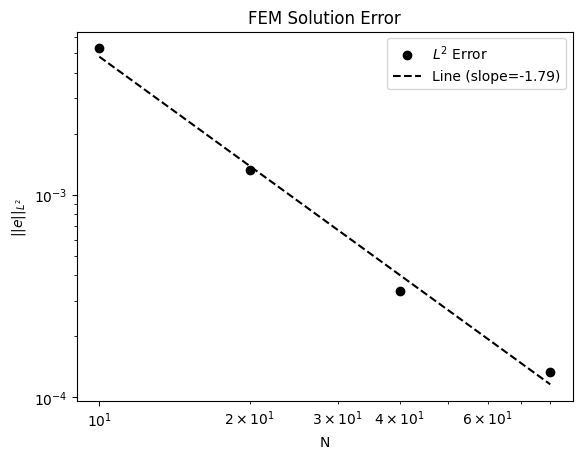

In [53]:
numRuns = 4
N = 5*(2**np.arange(1, numRuns+1))
errs = np.zeros(numRuns)
for k in range(numRuns):
    errs[k] = solve_poisson_problem(N[k])
    print(f"k={k}:  N={N[k]}, L2err={errs[k]:2.4e}", end="")
    if k > 0:
        order = np.log2(errs[k-1]/errs[k])
        print(f", order={order:.3f}", end="")
    print()

plot_convergence(errs, N)